In [10]:
import pandas as pd
import numpy as np
import random

np.random.seed(42)

nomes = ["Ana", "João", "Maria", "Pedro", "Lucas", "Julia", "Carlos", "Beatriz"]

dados = []

for _ in range(2000):
    nome = random.choice(nomes)

    idade = np.random.randint(18, 100)
    glicose = np.random.randint(70, 200)
    pressao = np.random.randint(90, 180)
    imc = round(np.random.uniform(18, 40), 1)
    colesterol = np.random.randint(150, 300)

    risco_score = 0

    if glicose > 160: risco_score += 2
    elif glicose > 120: risco_score += 1

    if pressao > 150: risco_score += 2
    elif pressao > 130: risco_score += 1

    if imc > 35: risco_score += 2
    elif imc > 28: risco_score += 1

    if colesterol > 260: risco_score += 2
    elif colesterol > 220: risco_score += 1

    if idade > 70: risco_score += 2
    elif idade > 50: risco_score += 1

    if risco_score <= 3:
        risco = 0  # baixo
    elif risco_score <= 6:
        risco = 1  # médio
    else:
        risco = 2  # alto

    dados.append([nome, idade, glicose, pressao, imc, colesterol, risco])

df = pd.DataFrame(dados, columns=[
    "nome", "idade", "glicose", "pressao", "imc", "colesterol", "risco"
])

df.to_csv("pacientes.csv", index=False)

print("Dataset criado com base no modelo biomédico!")
df.head()

Dataset criado com base no modelo biomédico!


,nome,idade,glicose,pressao,imc,colesterol,risco
0,Maria,69,162,104,34.1,170,1
1,Ana,92,157,113,32.3,202,1
2,João,19,157,119,22.7,170,0
3,Beatriz,50,127,111,18.2,238,0
4,Ana,66,128,131,19.0,164,0


In [18]:
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Carregar dados
df = pd.read_csv("pacientes.csv")

X = df.drop(columns=["nome", "risco"])
y = df["risco"]

# Divisão
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Normalização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Modelos
modelo_rf = RandomForestClassifier()
modelo_rf.fit(X_train, y_train)

modelo_lr = LogisticRegression(max_iter=1000)
modelo_lr.fit(X_train, y_train)

# RESULTADOS
resultados = {}

for nome, modelo in [("Random Forest", modelo_rf), ("Logistic Regression", modelo_lr)]:
    y_pred = modelo.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    resultados[nome] = acc

    print(f"\nModelo: {nome}")
    print("Acurácia:", acc)
    print(classification_report(y_test, y_pred))

# Validação cruzada
scores_rf = cross_val_score(modelo_rf, X_train, y_train, cv=5)
print("\nValidação cruzada (Random Forest):", scores_rf.mean())


Modelo: Random Forest
Acurácia: 0.9175
              precision    recall  f1-score   support

           0       0.96      0.93      0.95       142
           1       0.88      0.97      0.92       199
           2       0.98      0.71      0.82        59

    accuracy                           0.92       400
   macro avg       0.94      0.87      0.90       400
weighted avg       0.92      0.92      0.92       400


Modelo: Logistic Regression
Acurácia: 0.8525
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       142
           1       0.84      0.87      0.85       199
           2       0.90      0.78      0.84        59

    accuracy                           0.85       400
   macro avg       0.86      0.84      0.85       400
weighted avg       0.85      0.85      0.85       400


Validação cruzada (Random Forest): 0.9043749999999999


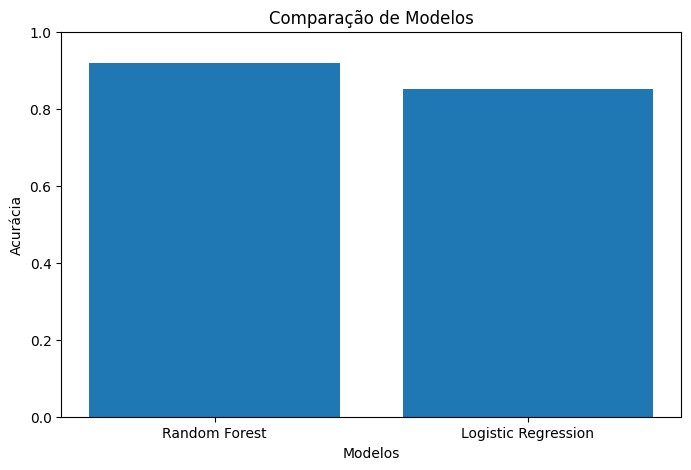

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(resultados.keys(), resultados.values())
plt.title("Comparação de Modelos")
plt.ylabel("Acurácia")
plt.xlabel("Modelos")
plt.ylim(0,1)
plt.show()

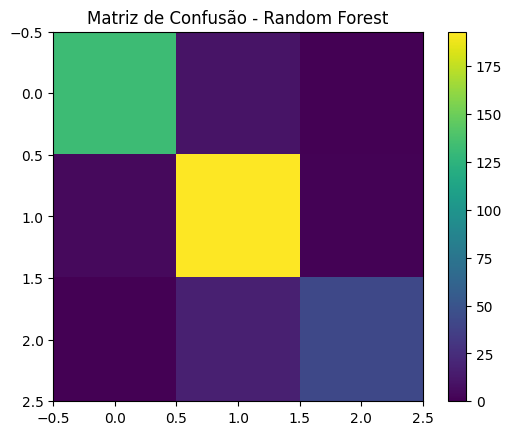

In [20]:
from sklearn.metrics import confusion_matrix

y_pred_rf = modelo_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)

plt.imshow(cm)
plt.title("Matriz de Confusão - Random Forest")
plt.colorbar()
plt.show()

In [21]:
novo_paciente = [[65, 180, 150, 32, 260]]

novo_paciente = scaler.transform(novo_paciente)

pred = modelo_rf.predict(novo_paciente)
prob = modelo_rf.predict_proba(novo_paciente)

print("Classe:", pred[0])
print("Probabilidade:", prob)

if pred[0] == 0:
    print("Baixo risco")
elif pred[0] == 1:
    print("Médio risco")
else:
    print("Alto risco")

Classe: 2
Probabilidade: [[0.   0.49 0.51]]
Alto risco


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [22]:
from google.colab import files
files.download("pacientes.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>